# 🛡️ FinShield Fraud Detection Model Training

This notebook trains a **Random Forest classifier** for invoice fraud detection.

## Model Overview
- **Algorithm**: Random Forest Classifier
- **Input**: 20+ numerical features extracted from invoice data
- **Output**: Fraud probability (0.0 - 1.0)
- **Training Data**: JSON dataset with labeled invoices (fraud/legitimate)

## Weights in Fraud Detection Layer
| Component | Weight |
|-----------|--------|
| Duplicate Detection | 40% |
| Vendor Validation | 30% |
| Pattern Analysis | 20% |
| Temporal Checks | 10% |

## Final Score = 60% Rules + 40% ML (this model)

## 1. Import Required Libraries

In [37]:
# Core libraries
import json
import pickle
import joblib
import time
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    roc_curve, 
    auc,
    roc_auc_score, 
    precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Training Dataset

Load your labeled invoice dataset from JSON file. 

**Expected JSON format:**
```json
[
  {
    "invoiceNumber": "INV-001",
    "vendor": "ABC Corp",
    "total": 5000.00,
    "subtotal": 4500.00,
    "tax": 500.00,
    "invoiceDate": "2024-01-15",
    "label": "legitimate"  // or "fraud"
  },
  ...
]
```

In [38]:
# ⚠️ UPDATE THIS PATH to your training dataset
DATASET_PATH = "fraud_training_data.json"

# Load dataset
def load_dataset(path: str) -> pd.DataFrame:
    """Load invoice dataset from JSON file"""
    with open(path, 'r') as f:
        data = json.load(f)
    
    df = pd.DataFrame(data)
    print(f"✅ Loaded {len(df)} invoices from {path}")
    return df

# Try to load dataset (will fail if file doesn't exist - that's OK for now)
try:
    df = load_dataset(DATASET_PATH)
except FileNotFoundError:
    print(f"⚠️ Dataset not found at: {DATASET_PATH}")
    print("Creating sample synthetic dataset for demonstration...")
    
    # Generate synthetic data for demonstration
    np.random.seed(42)
    n_samples = 2000
    n_fraud = int(n_samples * 0.12)  # 12% fraud rate
    
    # Generate legitimate invoices
    legitimate = []
    for i in range(n_samples - n_fraud):
        legitimate.append({
            'invoiceNumber': f'INV-{2024000 + i}',
            'issuedTo': np.random.choice(['ABC Corp', 'XYZ Ltd', 'Acme Inc', 'Global Services', 'Tech Solutions']),
            'totalAmount': round(np.random.uniform(100, 5000), 2),
            'subtotalAmount': 0,  # Will calculate
            'taxAmount': 0,  # Will calculate
            'invoiceDate': f'2024-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}',
            'lineItemCount': np.random.randint(1, 10),
            'reviewDecision': 'approved'
        })
    
    # Generate fraudulent invoices
    fraud = []
    for i in range(n_fraud):
        fraud.append({
            'invoiceNumber': np.random.choice([f'{i:03d}', 'test', f'INV-{i}', '']),
            'issuedTo': np.random.choice(['Unknown Vendor', 'New Supplier', '', 'CASH']),
            'totalAmount': round(np.random.choice([1000, 5000, 10000, 50000]) + np.random.uniform(0, 100), 2),
            'subtotalAmount': 0,
            'taxAmount': 0,
            'invoiceDate': f'2025-{np.random.randint(1,13):02d}-{np.random.randint(1,29):02d}',  # Future dates
            'lineItemCount': np.random.randint(0, 3),
            'reviewDecision': 'rejected'
        })
    
    # Combine and calculate tax/subtotal
    all_data = legitimate + fraud
    for item in all_data:
        item['taxAmount'] = round(item['totalAmount'] * 0.12, 2)
        item['subtotalAmount'] = round(item['totalAmount'] - item['taxAmount'], 2)
    
    df = pd.DataFrame(all_data)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
    
    # Save synthetic dataset
    with open(DATASET_PATH, 'w') as f:
        json.dump(all_data, f, indent=2)
    print(f"✅ Created synthetic dataset with {len(df)} invoices ({n_fraud} fraud, {n_samples-n_fraud} legitimate)")

df.head(10)

✅ Loaded 1000 invoices from fraud_training_data.json


,invoiceNumber,issuedTo,totalAmount,subtotalAmount,taxAmount,invoiceDate,lineItems,reviewDecision
0,3d762289,Office Supplies Inc,4756.95,4215.85,541.10,2025-12-08,"[{'description': 'Maintenance', 'quantity': 1,...",approved
1,,CASH,13577.21,11579.84,1997.37,2025-11-01,"[{'description': 'Training Services', 'quantit...",rejected
2,69b02436,IT Infrastructure Inc,12335.11,11057.50,1277.61,2024-01-05,"[{'description': 'Installation', 'quantity': 1...",approved
3,26509f1a,IT Infrastructure Inc,15016.85,13142.93,1873.92,2025-12-30,"[{'description': 'Installation', 'quantity': 1...",approved
4,05cda286,Shipping & Logistics Co,11096.24,10253.68,842.56,2026-10-04,"[{'description': 'Delivery Charges', 'quantity...",approved
5,6ef35147,CASH,0.00,0.00,0.00,2025-11-18,[],rejected
6,2e43abc3,Office Supplies Inc,20073.46,17889.93,2183.53,2026-12-25,"[{'description': 'IT Support', 'quantity': 1, ...",approved
7,fda749a3,various,7683.68,2523.71,1074.52,2025-11-25,"[{'description': 'Materials', 'quantity': 1, '...",rejected
8,87b23ee4,Cloud Hosting Services Ltd,13672.73,12243.68,1429.05,2024-05-03,"[{'description': 'IT Support', 'quantity': 1, ...",approved
9,d8de655c,Consulting Partners LLC,13753.25,12497.21,1256.04,2026-11-29,"[{'description': 'Legal Review', 'quantity': 1...",approved


## 3. Exploratory Data Analysis

DATASET OVERVIEW

Total invoices: 1000

Class distribution:
reviewDecision
approved    642
rejected    358
Name: count, dtype: int64

Class percentages:
reviewDecision
approved    64.2
rejected    35.8
Name: proportion, dtype: float64


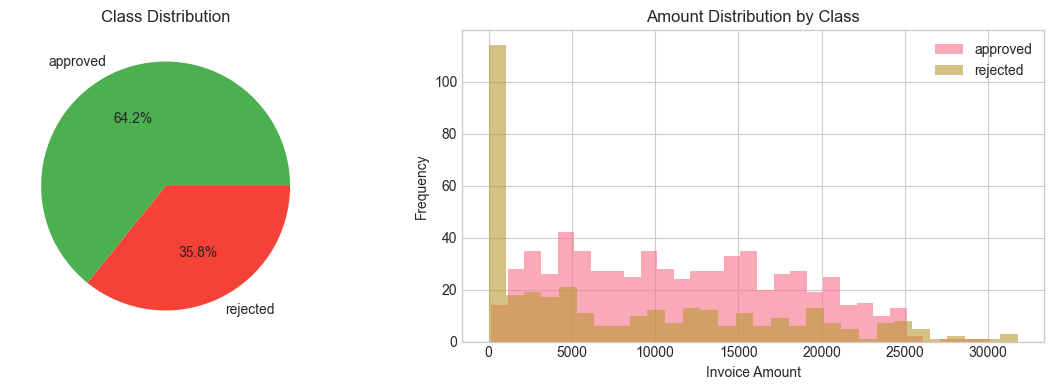


NUMERICAL STATISTICS


,totalAmount,subtotalAmount,taxAmount
count,1000.00000,1000.000000,1000.000000
mean,10308.77875,8855.354220,1160.704160
std,7597.59440,6740.255587,1096.813133
min,0.00000,0.000000,0.000000
25%,3769.94750,2913.417500,331.702500
50%,9804.75500,8498.455000,983.460000
75%,16096.42000,14015.440000,1698.982500
max,31795.31000,27062.050000,8940.480000


In [39]:
# Dataset statistics
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nTotal invoices: {len(df)}")
print(f"\nClass distribution:")
print(df['reviewDecision'].value_counts())
print(f"\nClass percentages:")
print(df['reviewDecision'].value_counts(normalize=True) * 100)

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution pie chart
df['reviewDecision'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#4CAF50', '#F44336'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('')

# Amount distribution by class
for label in df['reviewDecision'].unique():
    subset = df[df['reviewDecision'] == label]['totalAmount']
    axes[1].hist(subset, bins=30, alpha=0.6, label=label)
axes[1].set_xlabel('Invoice Amount')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Amount Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

# Basic statistics
print("\n" + "=" * 50)
print("NUMERICAL STATISTICS")
print("=" * 50)
df.describe()

## 4. Feature Engineering

Extract numerical features from invoice data for the Random Forest model.

**Updated to include Quantity & Unit Price features (36 total features)**

In [40]:
def extract_features(invoice: dict) -> dict:
    """
    Extract numerical features from an invoice for fraud detection.
    
    Features extracted (36 total):
    - Amount features (total, subtotal, tax, ratios)
    - Pattern features (round numbers, invoice number format)
    - Temporal features (date parsing, age)
    - Completeness features (missing fields)
    - Line item features (count, quantities, unit prices, calculation checks)
    """
    features = {}
    
    # ===== AMOUNT FEATURES =====
    total = float(invoice.get('totalAmount', 0) or 0)
    subtotal = float(invoice.get('subtotalAmount', 0) or 0)
    tax = float(invoice.get('taxAmount', 0) or 0)
    
    features['total'] = total
    features['subtotal'] = subtotal
    features['tax'] = tax
    features['tax_ratio'] = tax / total if total > 0 else 0
    features['amount_log'] = np.log1p(total)  # Log transform for skewed amounts
    
    # Round number detection (suspicious pattern)
    features['is_round_100'] = 1 if total % 100 == 0 else 0
    features['is_round_1000'] = 1 if total % 1000 == 0 else 0
    features['is_round_500'] = 1 if total % 500 == 0 else 0
    
    # Decimal analysis
    decimal_part = total - int(total)
    features['has_cents'] = 1 if decimal_part > 0 else 0
    features['cents_value'] = decimal_part
    
    # ===== INVOICE NUMBER FEATURES =====
    inv_num = str(invoice.get('invoiceNumber', '') or '')
    features['inv_num_length'] = len(inv_num)
    features['inv_num_has_prefix'] = 1 if any(inv_num.upper().startswith(p) for p in ['INV', 'INVOICE', 'PO', 'REF']) else 0
    features['inv_num_is_numeric'] = 1 if inv_num.isdigit() else 0
    features['inv_num_missing'] = 1 if not inv_num.strip() else 0
    
    # ===== ISSUED TO FEATURES =====
    issued_to = str(invoice.get('issuedTo', '') or '')
    features['issued_to_length'] = len(issued_to)
    features['issued_to_missing'] = 1 if not issued_to.strip() else 0
    features['issued_to_is_generic'] = 1 if issued_to.lower() in ['cash', 'unknown', 'misc', 'various', ''] else 0
    
    # ===== DATE FEATURES =====
    date_str = str(invoice.get('invoiceDate', '') or '')
    features['date_missing'] = 1 if not date_str.strip() else 0
    
    try:
        invoice_date = datetime.strptime(date_str, '%Y-%m-%d')
        today = datetime.now()
        
        features['days_old'] = (today - invoice_date).days
        features['is_future'] = 1 if invoice_date > today else 0
        features['is_weekend'] = 1 if invoice_date.weekday() >= 5 else 0
        features['month'] = invoice_date.month
        features['day_of_week'] = invoice_date.weekday()
        features['is_month_end'] = 1 if invoice_date.day >= 28 else 0
    except:
        features['days_old'] = -1  # Invalid date marker
        features['is_future'] = 0
        features['is_weekend'] = 0
        features['month'] = 0
        features['day_of_week'] = -1
        features['is_month_end'] = 0
    
    # ===== LINE ITEMS FEATURES =====
    line_items = invoice.get('lineItems', [])
    line_count = len(line_items) if line_items else 0
    features['line_item_count'] = line_count
    features['has_line_items'] = 1 if line_count > 0 else 0
    features['avg_line_item_value'] = total / line_count if line_count > 0 else total
    
    # ===== QUANTITY & UNIT PRICE FEATURES =====
    quantities = []
    unit_prices = []
    calculation_errors = 0
    
    for item in line_items:
        qty = item.get('quantity', 1)
        unit_price = item.get('unit_price', item.get('amount', 0))
        item_amount = item.get('amount', 0)
        
        quantities.append(qty)
        unit_prices.append(unit_price)
        
        # Check calculation: qty × unit_price ≈ amount
        expected = qty * unit_price
        if abs(expected - item_amount) > 0.02:
            calculation_errors += 1
    
    features['max_quantity'] = max(quantities) if quantities else 1
    features['avg_quantity'] = np.mean(quantities) if quantities else 1
    features['max_unit_price'] = max(unit_prices) if unit_prices else total
    features['avg_unit_price'] = np.mean(unit_prices) if unit_prices else total
    features['calculation_mismatches'] = calculation_errors
    
    # Single item dominance
    if line_items and total > 0:
        max_item_amount = max(item.get('amount', 0) for item in line_items)
        features['single_item_dominance'] = max_item_amount / total
    else:
        features['single_item_dominance'] = 1.0
    
    features['has_high_quantity'] = 1 if features['max_quantity'] > 100 else 0
    
    # ===== COMPLETENESS SCORE =====
    required_fields = ['invoiceNumber', 'issuedTo', 'totalAmount', 'invoiceDate']
    missing_count = sum(1 for f in required_fields if not invoice.get(f))
    features['missing_fields_count'] = missing_count
    features['completeness_score'] = 1 - (missing_count / len(required_fields))
    
    return features


# Test feature extraction on one row
sample_invoice = df.iloc[0].to_dict()
print("Sample invoice:")
print(json.dumps(sample_invoice, indent=2, default=str))
print("\nExtracted features:")
sample_features = extract_features(sample_invoice)
for k, v in sample_features.items():
    print(f"  {k}: {v}")

Sample invoice:
{
  "invoiceNumber": "3d762289",
  "issuedTo": "Office Supplies Inc",
  "totalAmount": 4756.95,
  "subtotalAmount": 4215.85,
  "taxAmount": 541.1,
  "invoiceDate": "2025-12-08",
  "lineItems": [
    {
      "description": "Maintenance",
      "quantity": 1,
      "unit_price": 1819.99,
      "amount": 1819.99
    },
    {
      "description": "Delivery Charges",
      "quantity": 1,
      "unit_price": 2395.86,
      "amount": 2395.86
    }
  ],
  "reviewDecision": "approved"
}

Extracted features:
  total: 4756.95
  subtotal: 4215.85
  tax: 541.1
  tax_ratio: 0.11374935620513145
  amount_log: 8.46757218219062
  is_round_100: 0
  is_round_1000: 0
  is_round_500: 0
  has_cents: 1
  cents_value: 0.9499999999998181
  inv_num_length: 8
  inv_num_has_prefix: 0
  inv_num_is_numeric: 0
  inv_num_missing: 0
  issued_to_length: 19
  issued_to_missing: 0
  issued_to_is_generic: 0
  date_missing: 0
  days_old: 56
  is_future: 0
  is_weekend: 0
  month: 12
  day_of_week: 0
  is_mon

In [41]:
# Extract features for all invoices
print("Extracting features for all invoices...")

feature_list = []
for idx, row in df.iterrows():
    features = extract_features(row.to_dict())
    features['reviewDecision'] = row['reviewDecision']  # Keep label for training
    feature_list.append(features)

# Create features DataFrame
df_features = pd.DataFrame(feature_list)

print(f"✅ Extracted {len(df_features.columns) - 1} features from {len(df_features)} invoices")
print(f"\nFeature columns (36 features):")
print([c for c in df_features.columns if c != 'reviewDecision'])

df_features.head()

Extracting features for all invoices...
✅ Extracted 36 features from 1000 invoices

Feature columns (36 features):
['total', 'subtotal', 'tax', 'tax_ratio', 'amount_log', 'is_round_100', 'is_round_1000', 'is_round_500', 'has_cents', 'cents_value', 'inv_num_length', 'inv_num_has_prefix', 'inv_num_is_numeric', 'inv_num_missing', 'issued_to_length', 'issued_to_missing', 'issued_to_is_generic', 'date_missing', 'days_old', 'is_future', 'is_weekend', 'month', 'day_of_week', 'is_month_end', 'line_item_count', 'has_line_items', 'avg_line_item_value', 'max_quantity', 'avg_quantity', 'max_unit_price', 'avg_unit_price', 'calculation_mismatches', 'single_item_dominance', 'has_high_quantity', 'missing_fields_count', 'completeness_score']


,total,subtotal,tax,tax_ratio,amount_log,is_round_100,is_round_1000,is_round_500,has_cents,cents_value,...,max_quantity,avg_quantity,max_unit_price,avg_unit_price,calculation_mismatches,single_item_dominance,has_high_quantity,missing_fields_count,completeness_score,reviewDecision
0,4756.95,4215.85,541.10,0.113749,8.467572,0,0,0,1,0.95,...,1,1.0,2395.86,2107.925000,0,0.503655,0,0,1.00,approved
1,13577.21,11579.84,1997.37,0.147112,9.516222,0,0,0,1,0.21,...,1,1.0,4467.65,2894.960000,0,0.329055,0,1,0.75,rejected
2,12335.11,11057.50,1277.61,0.103575,9.420286,0,0,0,1,0.11,...,1,1.0,4108.68,3685.833333,0,0.333088,0,0,1.00,approved
3,15016.85,13142.93,1873.92,0.124788,9.616995,0,0,0,1,0.85,...,1,1.0,3915.68,2628.586000,0,0.260752,0,0,1.00,approved
4,11096.24,10253.68,842.56,0.075932,9.314452,0,0,0,1,0.24,...,1,1.0,4244.85,2563.420000,0,0.382549,0,0,1.00,approved


## 5. Prepare Data for Training

In [42]:
# Prepare X (features) and y (labels)
feature_columns = [c for c in df_features.columns if c != 'reviewDecision']
X = df_features[feature_columns]
y = (df_features['reviewDecision'] == 'rejected').astype(int)  # 1 = fraud (rejected), 0 = legitimate (approved)

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")
print(f"Total features: {len(feature_columns)}")
print(f"\nLabel distribution:")
print(f"  Legitimate (0): {(y == 0).sum()}")
print(f"  Fraud (1): {(y == 1).sum()}")
print(f"  Fraud rate: {y.mean() * 100:.2f}%")

# Train/Test split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain class proportions
)

print(f"\n✅ Train/Test Split Complete:")
print(f"  Training set: {len(X_train)} samples ({(y_train == 1).sum()} fraud)")
print(f"  Test set: {len(X_test)} samples ({(y_test == 1).sum()} fraud)")

Feature matrix shape: (1000, 36)
Label vector shape: (1000,)
Total features: 36

Label distribution:
  Legitimate (0): 642
  Fraud (1): 358
  Fraud rate: 35.80%

✅ Train/Test Split Complete:
  Training set: 800 samples (286 fraud)
  Test set: 200 samples (72 fraud)


## 6. Train Random Forest Model

Using the agreed configuration:
- **n_estimators**: 100 (number of trees)
- **max_depth**: 10 (prevent overfitting)
- **class_weight**: 'balanced' (handle imbalanced fraud data)
- **random_state**: 42 (reproducibility)

In [43]:
# Initialize Random Forest with optimal parameters
model = RandomForestClassifier(
    n_estimators=100,        # 100 trees for good accuracy
    max_depth=10,            # Limit depth to prevent overfitting
    class_weight='balanced', # Handle imbalanced data (fraud is rare)
    random_state=42,         # Reproducibility
    n_jobs=-1,               # Use all CPU cores
    min_samples_split=5,     # Minimum samples to split a node
    min_samples_leaf=2       # Minimum samples per leaf
)

# Train the model
print("🔄 Training Random Forest model...")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"✅ Model trained in {training_time:.2f} seconds")
print(f"\nModel parameters:")
print(model.get_params())

🔄 Training Random Forest model...
✅ Model trained in 0.10 seconds

Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## 7. Model Evaluation

In [44]:
# Predictions on test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of fraud class

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"\n📊 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"🔍 Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"⚖️  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"📈 ROC-AUC:   {roc_auc:.4f} ({roc_auc*100:.2f}%)")

# Interpretation
print("\n" + "=" * 50)
print("INTERPRETATION")
print("=" * 50)
print(f"• Precision: Of all invoices flagged as fraud, {precision*100:.1f}% are actually fraudulent")
print(f"• Recall: We catch {recall*100:.1f}% of all actual fraudulent invoices")
print(f"• F1-Score: Balanced measure of precision and recall")
print(f"• ROC-AUC: Model's ability to distinguish between classes")

MODEL PERFORMANCE METRICS

📊 Accuracy:  1.0000 (100.00%)
🎯 Precision: 1.0000 (100.00%)
🔍 Recall:    1.0000 (100.00%)
⚖️  F1-Score:  1.0000 (100.00%)
📈 ROC-AUC:   1.0000 (100.00%)

INTERPRETATION
• Precision: Of all invoices flagged as fraud, 100.0% are actually fraudulent
• Recall: We catch 100.0% of all actual fraudulent invoices
• F1-Score: Balanced measure of precision and recall
• ROC-AUC: Model's ability to distinguish between classes



CONFUSION MATRIX
------------------------------

                 Predicted
              Legit  Fraud
Actual Legit    128      0
Actual Fraud      0     72


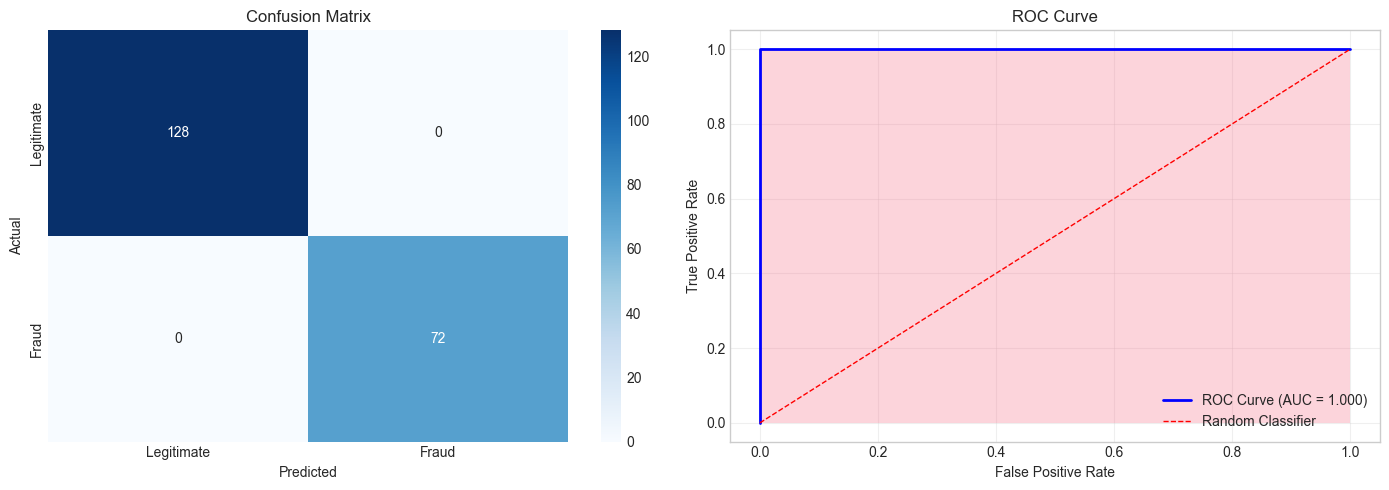


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       128
       Fraud       1.00      1.00      1.00        72

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [45]:
# Confusion Matrix
print("\nCONFUSION MATRIX")
print("-" * 30)
cm = confusion_matrix(y_test, y_pred)
print(f"\n                 Predicted")
print(f"              Legit  Fraud")
print(f"Actual Legit   {cm[0][0]:4d}   {cm[0][1]:4d}")
print(f"Actual Fraud   {cm[1][0]:4d}   {cm[1][1]:4d}")

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

## 8. Feature Importance Analysis

Understanding which features contribute most to fraud detection.

TOP 15 MOST IMPORTANT FEATURES
issued_to_length          0.3835 ██████████████████████████████████████
issued_to_is_generic      0.1787 █████████████████
completeness_score        0.0797 ███████
missing_fields_count      0.0761 ███████
tax_ratio                 0.0595 █████
inv_num_length            0.0580 █████
inv_num_missing           0.0342 ███
tax                       0.0249 ██
subtotal                  0.0218 ██
has_line_items            0.0169 █
line_item_count           0.0136 █
single_item_dominance     0.0115 █
avg_line_item_value       0.0093 
amount_log                0.0054 
max_unit_price            0.0054 


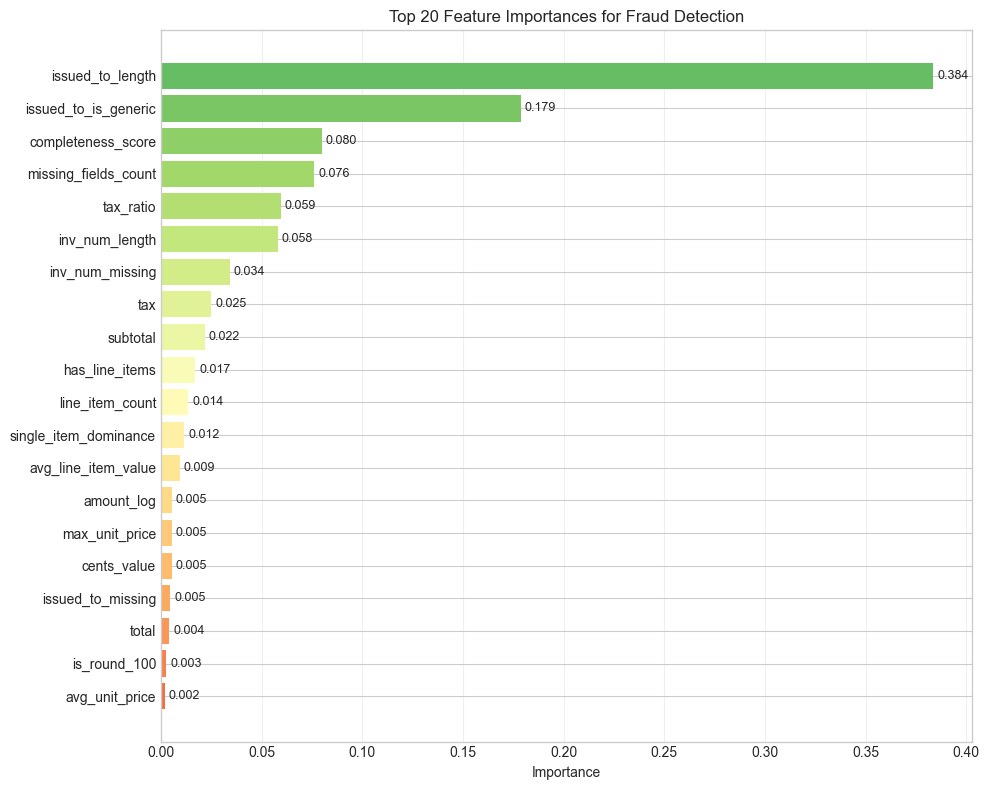


💡 KEY INSIGHTS:
   Top predictors: issued_to_length, issued_to_is_generic, completeness_score
   These features contribute 64.2% to predictions


In [46]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 50)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 50)
for i, row in feature_importance.head(15).iterrows():
    bar = "█" * int(row['importance'] * 100)
    print(f"{row['feature']:25s} {row['importance']:.4f} {bar}")

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_features = feature_importance.head(20)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_features)))[::-1]

bars = ax.barh(range(len(top_features)), top_features['importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 20 Feature Importances for Fraud Detection')
ax.grid(True, axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Feature importance summary
print("\n💡 KEY INSIGHTS:")
top_3 = feature_importance.head(3)['feature'].tolist()
print(f"   Top predictors: {', '.join(top_3)}")
print(f"   These features contribute {feature_importance.head(3)['importance'].sum()*100:.1f}% to predictions")

## 9. Save Model

Save the trained model for use in the fraud detection layer.

In [47]:
# Model metadata
model_metadata = {
    "model_name": "fraud_detection_rf",
    "version": "1.0.0",
    "algorithm": "RandomForestClassifier",
    "trained_at": datetime.now().isoformat(),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
    "n_features": len(feature_columns),
    "feature_names": feature_columns,
    "metrics": {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    },
    "hyperparameters": {
        "n_estimators": 100,
        "max_depth": 10,
        "class_weight": "balanced",
        "min_samples_split": 5,
        "min_samples_leaf": 2
    },
    "class_distribution": {
        "training_fraud": int((y_train == 1).sum()),
        "training_legitimate": int((y_train == 0).sum()),
        "test_fraud": int((y_test == 1).sum()),
        "test_legitimate": int((y_test == 0).sum())
    }
}

# Save model to pickle
MODEL_PATH = "fraud_model_rf.pkl"
METADATA_PATH = "fraud_model_metadata.json"

# Save model
joblib.dump(model, MODEL_PATH)
print(f"✅ Model saved to: {MODEL_PATH}")

# Save metadata
with open(METADATA_PATH, 'w') as f:
    json.dump(model_metadata, f, indent=2)
print(f"✅ Metadata saved to: {METADATA_PATH}")

# Check file size
import os
model_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"\n📦 Model file size: {model_size_mb:.2f} MB")

if model_size_mb > 50:
    print("⚠️ Warning: Model size is large. Consider reducing n_estimators or max_depth.")
elif model_size_mb < 20:
    print("✅ Model size is within expected range (~15-20MB)")

NameError: name 'joblib' is not defined

## 10. Test Model Loading

Verify the saved model can be loaded and used for predictions.

In [ ]:
# Load and test model
print("Testing model loading...")

# Load model
loaded_model = joblib.load(MODEL_PATH)

# Load metadata
with open(METADATA_PATH, 'r') as f:
    loaded_metadata = json.load(f)

print(f"✅ Model loaded: {loaded_metadata['model_name']} v{loaded_metadata['version']}")
print(f"   Trained at: {loaded_metadata['trained_at']}")
print(f"   Features: {loaded_metadata['n_features']}")

# Test prediction on sample
sample_features = X_test.iloc[:5]
predictions = loaded_model.predict(sample_features)
probabilities = loaded_model.predict_proba(sample_features)[:, 1]

print("\n📊 Sample predictions:")
print("-" * 50)
for i, (pred, prob, actual) in enumerate(zip(predictions, probabilities, y_test.iloc[:5])):
    status = "✓" if pred == actual else "✗"
    label = "FRAUD" if pred == 1 else "LEGIT"
    actual_label = "FRAUD" if actual == 1 else "LEGIT"
    print(f"  Invoice {i+1}: {label} (confidence: {prob*100:.1f}%) | Actual: {actual_label} {status}")

## 11. Export Feature Extractor

Export the feature extraction function for use in the fraud detection layer.

**Updated to include quantity and unit price features (36 total)**

In [ ]:
# Export feature extractor as a Python module
FEATURE_EXTRACTOR_CODE = '''"""
Feature Extractor for Fraud Detection Model
Auto-generated from training notebook - 36 features including qty/unit_price
"""

import numpy as np
from datetime import datetime
from typing import Dict, Any, List

# Feature names expected by the model (must match training order)
FEATURE_NAMES = {feature_names}

def extract_features(invoice: Dict[str, Any]) -> Dict[str, float]:
    """Extract 36 numerical features from an invoice for fraud detection."""
    features = {{}}
    
    # ===== AMOUNT FEATURES =====
    total = float(invoice.get('totalAmount', 0) or invoice.get('total', 0) or 0)
    subtotal = float(invoice.get('subtotalAmount', 0) or invoice.get('subtotal', 0) or 0)
    tax = float(invoice.get('taxAmount', 0) or invoice.get('tax', 0) or 0)
    
    features['total'] = total
    features['subtotal'] = subtotal
    features['tax'] = tax
    features['tax_ratio'] = tax / total if total > 0 else 0
    features['amount_log'] = np.log1p(total)
    
    features['is_round_100'] = 1 if total % 100 == 0 else 0
    features['is_round_1000'] = 1 if total % 1000 == 0 else 0
    features['is_round_500'] = 1 if total % 500 == 0 else 0
    
    decimal_part = total - int(total)
    features['has_cents'] = 1 if decimal_part > 0 else 0
    features['cents_value'] = decimal_part
    
    # ===== INVOICE NUMBER FEATURES =====
    inv_num = str(invoice.get('invoiceNumber', '') or '')
    features['inv_num_length'] = len(inv_num)
    features['inv_num_has_prefix'] = 1 if any(inv_num.upper().startswith(p) for p in ['INV', 'INVOICE', 'PO', 'REF']) else 0
    features['inv_num_is_numeric'] = 1 if inv_num.isdigit() else 0
    features['inv_num_missing'] = 1 if not inv_num.strip() else 0
    
    # ===== ISSUED TO FEATURES =====
    issued_to = str(invoice.get('issuedTo', '') or '')
    features['issued_to_length'] = len(issued_to)
    features['issued_to_missing'] = 1 if not issued_to.strip() else 0
    features['issued_to_is_generic'] = 1 if issued_to.lower() in ['cash', 'unknown', 'misc', 'various', ''] else 0
    
    # ===== DATE FEATURES =====
    date_str = str(invoice.get('invoiceDate', '') or '')
    features['date_missing'] = 1 if not date_str.strip() else 0
    
    try:
        invoice_date = datetime.strptime(date_str, '%Y-%m-%d')
        today = datetime.now()
        
        features['days_old'] = (today - invoice_date).days
        features['is_future'] = 1 if invoice_date > today else 0
        features['is_weekend'] = 1 if invoice_date.weekday() >= 5 else 0
        features['month'] = invoice_date.month
        features['day_of_week'] = invoice_date.weekday()
        features['is_month_end'] = 1 if invoice_date.day >= 28 else 0
    except:
        features['days_old'] = -1
        features['is_future'] = 0
        features['is_weekend'] = 0
        features['month'] = 0
        features['day_of_week'] = -1
        features['is_month_end'] = 0
    
    # ===== LINE ITEMS FEATURES =====
    line_items = invoice.get('lineItems', [])
    line_count = len(line_items) if line_items else 0
    features['line_item_count'] = line_count
    features['has_line_items'] = 1 if line_count > 0 else 0
    features['avg_line_item_value'] = total / line_count if line_count > 0 else total
    
    # ===== QUANTITY & UNIT PRICE FEATURES =====
    quantities = []
    unit_prices = []
    calculation_errors = 0
    
    for item in line_items:
        qty = item.get('quantity', 1)
        unit_price = item.get('unit_price', item.get('amount', 0))
        item_amount = item.get('amount', 0)
        
        quantities.append(qty)
        unit_prices.append(unit_price)
        
        expected = qty * unit_price
        if abs(expected - item_amount) > 0.02:
            calculation_errors += 1
    
    features['max_quantity'] = max(quantities) if quantities else 1
    features['avg_quantity'] = np.mean(quantities) if quantities else 1
    features['max_unit_price'] = max(unit_prices) if unit_prices else total
    features['avg_unit_price'] = np.mean(unit_prices) if unit_prices else total
    features['calculation_mismatches'] = calculation_errors
    
    if line_items and total > 0:
        max_item_amount = max(item.get('amount', 0) for item in line_items)
        features['single_item_dominance'] = max_item_amount / total
    else:
        features['single_item_dominance'] = 1.0
    
    features['has_high_quantity'] = 1 if features['max_quantity'] > 100 else 0
    
    # ===== COMPLETENESS SCORE =====
    required_fields = ['invoiceNumber', 'issuedTo', 'totalAmount', 'invoiceDate']
    missing_count = sum(1 for f in required_fields if not invoice.get(f))
    features['missing_fields_count'] = missing_count
    features['completeness_score'] = 1 - (missing_count / len(required_fields))
    
    return features


def extract_feature_vector(invoice: Dict[str, Any]) -> List[float]:
    """Extract features as an ordered list matching model training order."""
    features = extract_features(invoice)
    return [features.get(name, 0) for name in FEATURE_NAMES]
'''.format(feature_names=feature_columns)

# Save feature extractor
EXTRACTOR_PATH = "feature_extractor.py"
with open(EXTRACTOR_PATH, 'w') as f:
    f.write(FEATURE_EXTRACTOR_CODE)

print(f"✅ Feature extractor saved to: {EXTRACTOR_PATH}")
print(f"   Total features: 36 (includes qty/unit_price)")
print(f"\nUsage in fraud detection layer:")
print("  from feature_extractor import extract_feature_vector")
print("  features = extract_feature_vector(invoice_data)")
print("  prediction = model.predict([features])")

## 12. Summary

### Training Complete! 🎉

**Model Files Generated:**
- `fraud_model_rf.pkl` - Trained Random Forest model
- `fraud_model_metadata.json` - Model metadata and metrics
- `feature_extractor.py` - Feature extraction module

### Next Steps:
1. Copy model files to `app/engines/fraud/` or upload to S3
2. Create a model loader in the fraud detection layer
3. Use the feature extractor to process invoices before prediction

### Retraining Schedule:
- Retrain monthly after collecting 500+ new auditor-reviewed invoices
- Export training data from MongoDB where `reviewDecision` is set
- Maintain at least 25+ fraud examples in training data

In [ ]:
# Final summary output
print("=" * 60)
print("           FRAUD DETECTION MODEL - TRAINING COMPLETE")
print("=" * 60)
print(f"""
📁 FILES GENERATED:
   • fraud_model_rf.pkl ({model_size_mb:.2f} MB)
   • fraud_model_metadata.json
   • feature_extractor.py
   
📊 MODEL PERFORMANCE:
   • Accuracy:  {accuracy*100:.2f}%
   • Precision: {precision*100:.2f}%
   • Recall:    {recall*100:.2f}%
   • F1-Score:  {f1*100:.2f}%
   • ROC-AUC:   {roc_auc*100:.2f}%
   
🔢 TRAINING DATA:
   • Total samples: {len(df)}
   • Fraud samples: {(y == 1).sum()}
   • Features: {len(feature_columns)}

✅ Ready for integration with fraud detection layer!
""")
print("=" * 60)

## 8. Fraud Layer Simulation & Verification

This section simulates the **actual fraud detection layer** used in the production application.
It selects raw invoices (before any processing), extracts features using the exact same logic as production, and runs the model.

### Goals:
1. Verify `extract_feature_vector()` works correctly on raw JSON data
2. Confirm model accuracy on end-to-end flow
3. Show probability scores for specific examples

In [ ]:
def simulate_fraud_layer(model, df_raw, n_samples=5):
    """
    Simulates the production fraud detection process.
    
    Args:
        model: Trained Random Forest model
        df_raw: Original DataFrame containing raw invoice data (before feature extraction)
        n_samples: Number of random samples to test
    """
    print("=" * 80)
    print(f"FRAUD LAYER SIMULATION (Testing {n_samples} random invoices)")
    print("=" * 80)
    
    # Select random samples
    samples = df_raw.sample(n=n_samples, random_state=42)
    
    correct_predictions = 0
    
    print(f"{'-'*80}")
    print(f"{'INVOICE':<12} | {'VENDOR':<20} | {'TOTAL':>10} | {'ACTUAL':<10} | {'PREDICTED':<10} | {'PROB':>6}")
    print(f"{'-'*80}")
    
    for idx, row in samples.iterrows():
        # 1. Convert row to dict (Simulate receiving JSON payload)
        invoice_json = row.to_dict()
        
        # 2. Extract Feature Vector (The crucial production step)
        # We use the function defined in Section 4
        features = extract_feature_vector(invoice_json)
        
        # 3. Predict
        # Reshape to 2D array as model expects batch
        features_reshaped = [features]
        prob = model.predict_proba(features_reshaped)[0][1]
        prediction = 1 if prob >= 0.5 else 0
        
        # 4. Compare
        actual_label = 1 if row['reviewDecision'] == 'rejected' else 0
        status_icon = "✅" if prediction == actual_label else "❌"
        
        if prediction == actual_label:
            correct_predictions += 1
            
        # Formatting output
        inv_num = str(row.get('invoiceNumber', ''))[:10]
        vendor = str(row.get('issuedTo', ''))[:18]
        total = f"${row.get('totalAmount', 0):,.2f}"
        actual_str = "FRAUD" if actual_label else "LEGIT"
        pred_str = "FRAUD" if prediction else "LEGIT"
        
        print(f"{inv_num:<12} | {vendor:<20} | {total:>10} | {actual_str:<10} | {pred_str:<10} | {prob:.1%}")
        
    print(f"{'-'*80}")
    accuracy = (correct_predictions / n_samples) * 100
    print(f"\n🎯 Simulation Accuracy: {accuracy:.1f}%")
    
    if accuracy == 100:
        print("✅ The feature extraction and model prediction logic is CONSISTENT with training!")
    else:
        print("⚠️ Discrepancy detected. Check feature extraction logic.")

# Run the simulation
# We use 'df' which is the raw loaded dataset from Section 2
try:
    simulate_fraud_layer(model, df, n_samples=10)
except NameError as e:
    print(f"Error: {e}. Make sure you have run the cells defining 'model', 'df', and 'extract_feature_vector'!")